In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dataset_first = pd.read_csv("yuzde90.csv")

In [3]:
deneme = dataset_first.copy()
df = dataset_first.copy()


In [4]:
deneme.head()


,Fiyat,Oda Sayısı,Metrekare,Bina Yaşı,Kat Durumu,Bina Konumu
0,9.750.000\nTL,4 + 1,200 m²,28 Yaşında,3. Kat,Ankara / Çankaya / Ayrancı Mah.
1,1.530.000\nTL,1 + 1,45 m²,Sıfır Bina,Yüksek Giriş,Ankara / Keçiören / Şenyuva Mah.
2,17.850.000\nTL,5 + 1,330 m²,Sıfır Bina,NaN,Ankara / Etimesgut / Bağlıca Mah.
3,2.575.000\nTL,2 + 1,105 m²,15 Yaşında,1. Kat,Ankara / Mamak / General Zeki Doğan Mah.
4,4.600.000\nTL,3 + 1,110 m²,Sıfır Bina,1. Kat,Ankara / Gölbaşı / Eymir Mah.


In [5]:
deneme.isna().sum()


Fiyat            0
Oda Sayısı       0
Metrekare        0
Bina Yaşı        0
Kat Durumu     105
Bina Konumu      0
dtype: int64

In [6]:
# 1. Fiyat sütunundan gereksiz karakterleri kaldırıp dönüştürme
df['Fiyat'] = df['Fiyat'].astype(str)  # Fiyat sütununu string'e çevir
df['Fiyat'] = df['Fiyat'].str.replace(r'\D', '', regex=True)  # Sayısal olmayan karakterleri kaldır
df['Fiyat'] = df['Fiyat'].fillna('0').astype(int)  # NaN değerleri 0 ile doldur ve int'e çevir

# 2. Oda Sayısı sütununda toplama işlemi yaparak sayıya çevirme
oda_sayisi = df['Oda Sayısı'].str.extract(r'(\d+)\s*\+\s*(\d+)').astype(float)  # Oda ve salon sayısını ayır
oda_sayisi = oda_sayisi.fillna(oda_sayisi.median())  # Medyan ile eksik değerleri doldur
df['Oda Sayısı'] = oda_sayisi.sum(axis=1).astype(int)  # Oda ve salonu toplamını alarak integer'a çevir

# 3. Metrekare sütunundan birimleri kaldırıp sayıya çevirme
df['Metrekare'] = df['Metrekare'].str.replace(r'[^\d]', '', regex=True)  # Sayısal olmayan karakterleri kaldır
df['Metrekare'] = df['Metrekare'].fillna('0').astype(int)  # NaN değerlerini 0 ile doldur ve int'e çevir

# 4. Bina Yaşı sütununu dönüştürme
df['Bina Yaşı'] = df['Bina Yaşı'].str.extract(r'(\d+)')  # Sadece sayıları al
df['Bina Yaşı'] = df['Bina Yaşı'].fillna('1').astype(int)  # Eksik değerleri 1 ile doldur (yeni bina için)
 
# 5. Bina Konumu sütununu ayrıştırma (Şehir, İlçe, Mahalle)
df[['Şehir', 'İlçe', 'Mahalle']] = df['Bina Konumu'].str.split(' / ', expand=True)  # Konumu ayır
df[['Şehir', 'İlçe', 'Mahalle']] = df[['Şehir', 'İlçe', 'Mahalle']].fillna('Bilinmiyor')  # Eksik değerleri 'Bilinmiyor' ile doldur
df.drop(columns=['Bina Konumu'], inplace=True)  # Bina Konumu sütununu kaldır

# 6. Diğer düzenlemeler (Eğer başka kategorik sütunlar varsa bunları kategorik hale getirme)
df['Şehir'] = df['Şehir'].astype('category').cat.codes  # Şehir sütununu kategorik hale getirme
df['İlçe'] = df['İlçe'].astype('category').cat.codes  # İlçe sütununu kategorik hale getirme
df['Mahalle'] = df['Mahalle'].astype('category').cat.codes  # Mahalle sütununu kategorik hale getirme


In [7]:
from sklearn.preprocessing import LabelEncoder

# Encoding işlemi: Kategorik verileri nümerik verilere dönüştürme
label_encoder = LabelEncoder()

# Kategorik sütunlar: Veri setinizdeki uygun sütunlar
categorical_columns = ['Kat Durumu', 'Şehir', 'İlçe', 'Mahalle']

# Kategorik sütunları dönüştürme
for column in categorical_columns:
    # Eksik değerleri kontrol edip doldurma
    if df[column].isnull().any():
        df[column] = df[column].fillna("Bilinmiyor")
    # Label encoding işlemi
    df[column] = label_encoder.fit_transform(df[column])

# Veri kümesi bilgilerini görüntüleme
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1759 entries, 0 to 1758
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Fiyat       1759 non-null   int32
 1   Oda Sayısı  1759 non-null   int32
 2   Metrekare   1759 non-null   int32
 3   Bina Yaşı   1759 non-null   int32
 4   Kat Durumu  1759 non-null   int32
 5   Şehir       1759 non-null   int64
 6   İlçe        1759 non-null   int64
 7   Mahalle     1759 non-null   int64
dtypes: int32(5), int64(3)
memory usage: 75.7 KB


In [8]:
df['Bina Yaşı'] = df['Bina Yaşı'].astype('category').cat.codes
df['Kat Durumu'] = df['Kat Durumu'].astype('category').cat.codes
df['Şehir'] = df['Şehir'].astype('category').cat.codes
df['İlçe'] = df['İlçe'].astype('category').cat.codes
df['Mahalle'] = df['Mahalle'].astype('category').cat.codes


In [9]:
print(df.isna().sum())

Fiyat         0
Oda Sayısı    0
Metrekare     0
Bina Yaşı     0
Kat Durumu    0
Şehir         0
İlçe          0
Mahalle       0
dtype: int64


NORMALİZASYON ADIMLARI VE AYKIRI DEĞER ANALİZİ

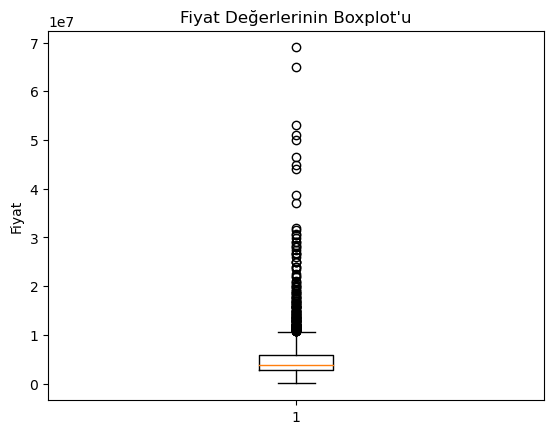

In [10]:

plt.boxplot(df['Fiyat'])
plt.title("Fiyat Değerlerinin Boxplot'u")
plt.ylabel("Fiyat")
plt.show()

In [11]:
df=df.head(800)
#veri ön işleme
a=df.iloc[:,0:2]
b=df.iloc[:,4:-1]
x = pd.concat([a, b], axis=1)
y = df.iloc[:,2]
X = x.values
Y = y.values

#verilerin egitim ve test icin bolunmesi
from sklearn.model_selection import train_test_split

x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.33, random_state=0)


Random forest

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score  # Burada gerekli fonksiyonları içe aktarın

# Random Forest modelini daha iyi parametrelerle eğitmek
rf_model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
rf_model.fit(x_train, y_train)

# Test seti üzerinde tahmin yapma
rf_y_pred = rf_model.predict(x_test)

# Performansı değerlendirme
rf_mse = mean_squared_error(y_test, rf_y_pred)
rf_r2 = r2_score(y_test, rf_y_pred)

print(f"Random Forest MSE: {rf_mse}")
print(f"Random Forest R² Score: {rf_r2}")


Random Forest MSE: 1906.9795332287133
Random Forest R² Score: 0.7470670377551286


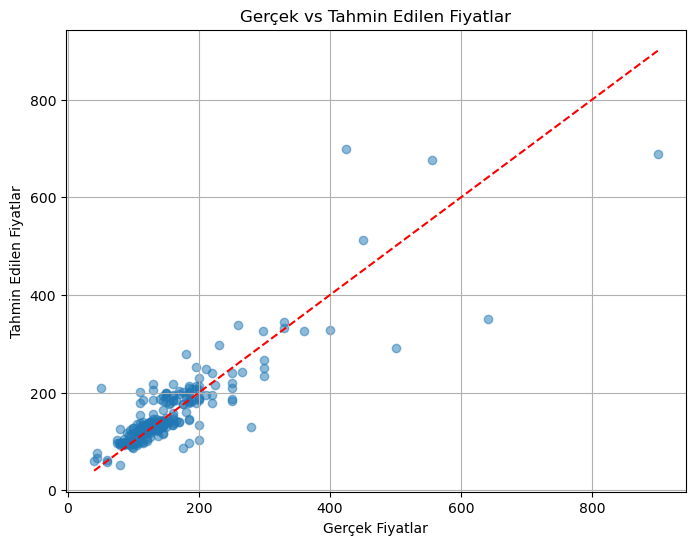

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color="red", linestyle="--")
plt.xlabel("Gerçek Fiyatlar")
plt.ylabel("Tahmin Edilen Fiyatlar")
plt.title("Gerçek vs Tahmin Edilen Fiyatlar")
plt.grid()
plt.show()

Lineer Regresyon


In [17]:
from sklearn.linear_model import LinearRegression


# Model oluşturma ve eğitme
model = LinearRegression()
model.fit(x_train, y_train)

# Test seti üzerinde tahmin yapma
y_pred = model.predict(x_test)

# Model performansını değerlendirme
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R² Score: {r2}")


Mean Squared Error (MSE): 2256.6661533415167
R² Score: 0.7006862186947489


XGBoost 

In [15]:
!pip install xgboost

In [18]:
from xgboost import XGBRegressor

# XGBoost modelini oluşturma
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Modeli eğitme
xgb_model.fit(x_train, y_train)

# Test seti üzerinde tahmin yapma
xgb_y_pred = xgb_model.predict(x_test)

# Model performansını değerlendirme
xgb_mse = mean_squared_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print(f"XGBoost Mean Squared Error (MSE): {xgb_mse}")
print(f"XGBoost R² Score: {xgb_r2}")


XGBoost Mean Squared Error (MSE): 2196.8994064138797
XGBoost R² Score: 0.7086134041106049
